# Collab code

For collab to download dataset from kaggle Brisc2025

In [ ]:
# Create the kaggle.json file with your credentials
!mkdir -p ~/.kaggle

# Replace 'your_username' with your actual Kaggle username
# Your API key is: KGAT_ff9d24c578d21a4340ae7b06f06cd5d8
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('''{
  "username": "amrbadawi",
  "key": "KGAT_ff9d24c578d21a4340ae7b06f06cd5d8"
}''')

# Set proper permissions
!chmod 600 ~/.kaggle/kaggle.json

# Or your specific dataset (replace with actual name)
!kaggle datasets download -d 'briscdataset/brisc2025'

!unzip -q 'brisc2025.zip'  # Replace with actual filename
!ls -la  # List files to confirm

For collab to download dataset from kaggle second dataset 

In [ ]:
# Download the Kaggle dataset
!kaggle datasets download -d 'indk214/brain-tumor-dataset-segmentation-and-classification'
!unzip -q 'brain-tumor-dataset-segmentation-and-classification.zip' -d 'second_dataset'
!ls 'second_dataset'   # inspect the folder structure

# import & Check GPU

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Current device: 0


In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from ultralytics import YOLO
import torch
from pathlib import Path
from tqdm import tqdm

# Preprocessing

In [ ]:
import cv2
import numpy as np

def preprocess_image(img):
    img = cv2.resize(img, (256, 256)) # change to 256 for yolo_seg_from_cls_256(x)4_deepseek
    # img = img.astype(np.float32)     
    return img

def preprocess_mask(mask, target_size=(256, 256)):
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    return mask

# Load Data

1st Create YAML file and Creating YOLO Format with preprocessing For Brisc 2025

In [ ]:
import json
import yaml
import shutil
import cv2
import numpy as np
from pathlib import Path

dataset_root = Path("../../Dataset/brisc2025")
output_root = Path("yolo_seg_dataset")
manifest_path = dataset_root / "manifest.json"

# Create folders
(output_root / "train/images").mkdir(parents=True, exist_ok=True)
(output_root / "train/masks").mkdir(parents=True, exist_ok=True)
(output_root / "test/images").mkdir(parents=True, exist_ok=True)
(output_root / "test/masks").mkdir(parents=True, exist_ok=True)

# Load manifest
with open(manifest_path) as f:
    manifest = json.load(f)

images = []
masks = {}

# Separate images and masks
for entry in manifest:
    if entry["task"] == "segmentation":
        if entry["is_mask"]:
            masks[entry["linked_image"]] = entry
        else:
            images.append(entry)

# Get class labels
labels = sorted({img["tumor_label"] for img in images})


for img in images:
    mask = masks.get(img["relative_path"])
    if not mask:
        print(f"Mask not found for {img['relative_path']}")
        continue

    split = img["split"]

    # Source paths
    img_src = dataset_root / img["relative_path"]
    mask_src = dataset_root / mask["relative_path"]

    # Destination paths
    img_dst = output_root / split / "images" / Path(img_src).name
    mask_dst = output_root / split / "masks" / Path(mask_src).name

    
    # ----- Process image -----
    img_bgr = cv2.imread(str(img_src))
    if img_bgr is None:
        print(f"Could not read image {img_src}")
        continue
    img_proc = preprocess_image(img_bgr)
    cv2.imwrite(str(img_dst), img_proc)

    # ----- Process mask -----
    # Masks are usually single‑channel; read as grayscale
    mask_gray = cv2.imread(str(mask_src), cv2.IMREAD_GRAYSCALE)
    if mask_gray is None:
        print(f"Could not read mask {mask_src}")
        continue
    mask_proc = preprocess_mask(mask_gray)
    cv2.imwrite(str(mask_dst), mask_proc)


yaml_data = {
    "path": str(output_root.resolve()),
    "train": "train/images",
    "val": "test/images",
    "nc": len(labels),
    "names": labels
}

with open(output_root / "dataset.yaml", "w") as f:
    yaml.dump(yaml_data, f)

print("Done. Images and masks have been Copied and preprocessed.")

Done. Images and masks have been Copied and preprocessed.


converts segmentation masks → YOLO segmentation label format as txt For brisc 2025 dataset - harsh/balanced (many lines not in actual png)

In [ ]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

# CONFIGURATION
output_root = Path("yolo_seg_dataset") # dataset folder
class_names = ['glioma', 'meningioma', 'pituitary']
class_to_id = {name: i for i, name in enumerate(class_names)}
code_to_name = {'gl': 'glioma', 'me': 'meningioma', 'pi': 'pituitary'}

# Balanced parameters (good for real-world)
MIN_CONTOUR_AREA = 10
EPSILON_FACTOR = 0.0005          # smoothing
MIN_POLYGON_POINTS = 3

# ------------------------------------------------------------
# Process each split
# ------------------------------------------------------------
for split in ["train", "test"]:
    image_dir = output_root / split / "images"
    mask_dir  = output_root / split / "masks"
    label_dir = output_root / split / "labels"
    label_dir.mkdir(parents=True, exist_ok=True)

    image_files = sorted(image_dir.glob("*.jpg"))
    print(f"\nProcessing {split} split: {len(image_files)} images")

    total_kept = 0
    total_discarded = 0

    for img_path in tqdm(image_files, desc=f"Converting masks for {split}"):
        base = img_path.stem

        # Find mask file with same stem
        mask_candidates = list(mask_dir.glob(base + ".*"))
        if not mask_candidates:
            print(f"  Warning: mask not found for {img_path.name}")
            continue
        mask_path = mask_candidates[0]

        # Read mask as color, then convert to grayscale
        mask_bgr = cv2.imread(str(mask_path))
        if mask_bgr is None:
            print(f"  Warning: could not read mask {mask_path}")
            continue
        mask_gray = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2GRAY)

        # Extract tumor code from filename
        parts = base.split('_')
        tumor_code = None
        for part in parts:
            if part in code_to_name:
                tumor_code = part
                break
        if tumor_code is None:
            print(f"  Warning: could not determine tumor code from filename {base}")
            continue
        class_id = class_to_id[code_to_name[tumor_code]]

        # Binary mask
        if np.count_nonzero(mask_gray) == 0:
            print(f"  Warning: mask {mask_path} is all zeros")
            continue

        bin_mask = (mask_gray > 0).astype(np.uint8) * 255

        # Find contours
        contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        label_lines = []
        h, w = mask_gray.shape

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < MIN_CONTOUR_AREA:
                total_discarded += 1
                continue

            epsilon = EPSILON_FACTOR * cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, epsilon, True)

            if len(approx) < MIN_POLYGON_POINTS:
                total_discarded += 1
                continue

            # Normalize coordinates
            norm_points = []
            for point in approx[:, 0, :]:
                x_norm = point[0] / w
                y_norm = point[1] / h
                x_norm = max(0.0, min(1.0, x_norm))
                y_norm = max(0.0, min(1.0, y_norm))
                norm_points.extend([x_norm, y_norm])

            line = f"{class_id} " + " ".join(f"{p:.6f}" for p in norm_points)
            label_lines.append(line)
            total_kept += 1

        if not label_lines:
            print(f"  Warning: no valid contours after filtering for {mask_path}")

        # Write label file
        label_file = label_dir / f"{base}.txt"
        with open(label_file, "w") as f:
            f.write("\n".join(label_lines))

    print(f"Split {split}: kept {total_kept} contours, discarded {total_discarded}")

print("\n✅ conversion complete. YOLO label files are ready.")

# Test Labels and loaded images

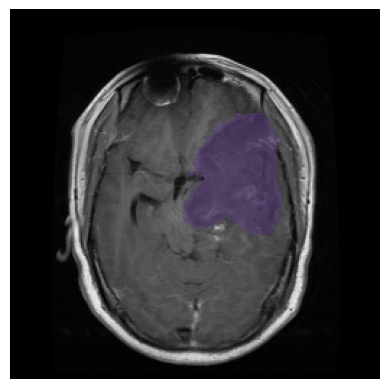

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (original size)
img_path = "yolo_seg_dataset/train/images/brisc2025_train_00001_gl_ax_t1.jpg" 
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Load label file
label_file = "yolo_seg_dataset/train/labels/brisc2025_train_00001_gl_ax_t1.txt"
with open(label_file) as f:
    lines = f.readlines()

# Create overlay
overlay = img.copy()
for line in lines:
    parts = line.strip().split()
    if len(parts) < 7:          
        continue
    class_id = int(parts[0])
    coords = list(map(float, parts[1:]))
    # convert normalized to pixel coordinates
    points = np.array([[int(coords[i] * w), int(coords[i+1] * h)] 
                       for i in range(0, len(coords), 2)], np.int32)
    # draw filled polygon with random color
    color = np.random.randint(0, 255, 3).tolist()
    cv2.fillPoly(overlay, [points], color)

# Blend with original
alpha = 0.5
blended = cv2.addWeighted(img, 1-alpha, overlay, alpha, 0)
plt.imshow(blended)
plt.axis('off')
plt.show()

Compare the actual png mask to the generated txt

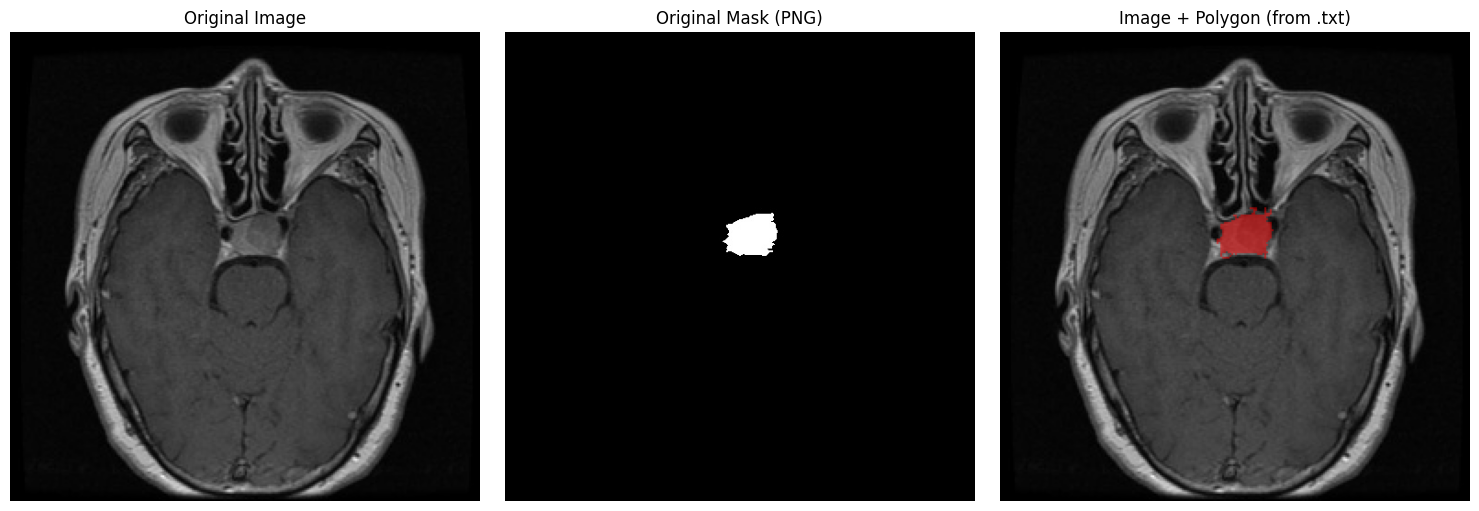

Image: yolo_seg_dataset\train\images\brisc2025_train_03734_pi_ax_t1.jpg
Label: yolo_seg_dataset\train\labels\brisc2025_train_03734_pi_ax_t1.txt
Original mask: ..\..\Dataset\brisc2025\segmentation_task\train\masks\brisc2025_train_03734_pi_ax_t1.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path

# Paths
yolo_root = Path("yolo_seg_dataset")               # your prepared YOLO dataset
original_dataset_root = Path("../../Dataset/brisc2025")  # original BRISC2025
seg_task_root = original_dataset_root / "segmentation_task"

# Pick a random image from YOLO train/images
img_folder = yolo_root / "train" / "images"
label_folder = yolo_root / "train" / "labels"

img_files = [f for f in os.listdir(img_folder) if f.endswith(('.jpg', '.png'))]
img_name = random.choice(img_files)
img_path = img_folder / img_name
label_path = label_folder / (img_name.rsplit('.', 1)[0] + '.txt')

# Load image
img_bgr = cv2.imread(str(img_path))
if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {img_path}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

# Find the original mask (PNG) from BRISC2025 dataset
split = img_path.parent.parent.name   # "train" or "test"
mask_original_folder = seg_task_root / split / "masks"
mask_original_path = mask_original_folder / (img_name.rsplit('.', 1)[0] + ".png")  # assume .png

if not mask_original_path.exists():
    # try .jpg if .png not found
    mask_original_path = mask_original_folder / (img_name.rsplit('.', 1)[0] + ".jpg")

if not mask_original_path.exists():
    print(f"Original mask not found for {img_name}")
    mask_original = None
else:
    mask_original = cv2.imread(str(mask_original_path), cv2.IMREAD_GRAYSCALE)

# Load YOLO .txt labels and draw polygons
overlay = img_rgb.copy()
if label_path.exists():
    with open(label_path) as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:   # need at least 3 points (6 coords)
            continue
        class_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        points = np.array([[int(coords[i] * w), int(coords[i+1] * h)] 
                           for i in range(0, len(coords), 2)], np.int32)
        # Ensure polygon is closed and has at least 3 points
        if len(points) >= 3:
            color = (255, 0, 0)   # red in RGB (for overlay)
            cv2.fillPoly(overlay, [points], color)
else:
    print(f"Label file not found: {label_path}")

# Blend
alpha = 0.5
blended = cv2.addWeighted(img_rgb, 1-alpha, overlay, alpha, 0)

# Display three images side by side
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
if mask_original is not None:
    plt.imshow(mask_original, cmap='gray')
    plt.title("Original Mask (PNG)")
else:
    plt.text(0.5, 0.5, "Mask not found", ha='center', va='center')
    plt.title("Original Mask")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blended)
plt.title("Image + Polygon (from .txt)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Also print the paths for verification
print(f"Image: {img_path}")
print(f"Label: {label_path}")
print(f"Original mask: {mask_original_path if mask_original is not None else 'Not found'}")

# Train the model

In [ ]:
# Load a pre-trained YOLOv8 segemntation model (Extra Large version)
model = YOLO('yolov8x-seg.pt')

model.load('../YOLO_classify/runs/classify/yolo_with_my_preproc/weights/best.pt')


Transferred 26/657 items from pretrained weights


YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 80, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(80, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(80, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(160, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(400, 160, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(160, eps=0.001, momentum=0.03, affine=True, trac

Model yolo_seg_from_cls_256(x)4 run

In [ ]:
model = YOLO('yolov8x-seg.pt')

model.load('../YOLO_classify/runs/classify/yolo_with_my_preproc/weights/best.pt')

model.train(
    data='yolo_seg_dataset/dataset.yaml',
    epochs=120,                     
    imgsz=256,                      
    batch=8,                        
    device=0,
    workers=2,

    # Loss weights – balanced for 256px
    box=0.8,                        # Slightly lower
    cls=0.1,
    mask_ratio=6,                   # ← Reduced from 8 (better for 256px)
    dfl=1.0,                        # ← Reduced from 1.5 (less box focus)

    # Regularization 
    dropout=0.1,                   
    weight_decay=0.0005,            

    # Mask quality
    overlap_mask=False,
    retina_masks=True,

    # Augmentation – same minimal set
    degrees=10.0,
    fliplr=0.5,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    translate=0.1,
    scale=0.5,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,

    # Optimization – slower LR for stability
    optimizer='AdamW',
    lr0=8e-4,                       
    lrf=0.01,
    momentum=0.937,
    warmup_epochs=5,                
    warmup_momentum=0.8,
    cos_lr=True,

    patience=30,                    
    name='yolo_seg_from_cls_256(x)4',   # based on deep seek suggitions 
)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.2 torch-2.2.0+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=0.8, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.1, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=yolo_seg_dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.0, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0008, lrf=0.01, mask_ratio=6, max_det=300, mixup=0.0, mode=train, model=yolov8x-seg.pt, momentum=0.937, mosaic=0.0, multi_scal

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002161AEE44A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    

# Evaluate the model

In [ ]:
# 1. Construct the correct path to the trained model file
model_path = os.path.join('runs', 'segment','yolo_seg_from_cls_256(x)4', 'weights', 'best.pt')

# 2. Load the model
model = YOLO(model_path)
model_dir = Path(model_path).parent.parent
csv_path=os.path.join(model_dir,'results.csv')
df = pd.read_csv(csv_path)
df.tail()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,train/sem_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),...,metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,val/sem_loss,lr/pg0,lr/pg1,lr/pg2
115,116,18454.6,0.07543,0.14139,0.06254,0.59607,0,0.89837,0.85458,0.89134,...,0.86681,0.51461,0.13555,0.21459,0.11155,0.87608,0,0.000011,0.000011,0.000011
116,117,18618.7,0.07557,0.14060,0.06276,0.59578,0,0.89991,0.85955,0.89440,...,0.86686,0.51585,0.13565,0.21456,0.11158,0.87736,0,0.000010,0.000010,0.000010
117,118,18779.1,0.07564,0.14077,0.06242,0.59870,0,0.89570,0.85976,0.89132,...,0.86820,0.51580,0.13572,0.21478,0.11166,0.87729,0,0.000009,0.000009,0.000009
118,119,18939.8,0.07543,0.14105,0.06231,0.59814,0,0.89665,0.86006,0.89281,...,0.86679,0.51495,0.13571,0.21499,0.11164,0.87669,0,0.000009,0.000009,0.000009
119,120,19099.1,0.07476,0.14136,0.06197,0.59530,0,0.89948,0.86106,0.89357,...,0.86580,0.51412,0.13568,0.21489,0.11175,0.87663,0,0.000008,0.000008,0.000008


Testing Evaluations

In [ ]:
from ultralytics import YOLO

# Load your trained model
model = YOLO('runs/segment/yolo_seg_from_cls_256(x)4/weights/best.pt')


metrics = model.val(data='yolo_seg_dataset/dataset.yaml', split='val', name="VAL_yolo_seg_from_cls_256(x)4")

# Print the test metrics
print(f"Test mAP50: {metrics.seg.map50}")
print(f"Test mAP50-95: {metrics.seg.map}")   

Ultralytics 8.4.21  Python-3.12.2 torch-2.2.0+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
YOLOv8x-seg summary (fused): 126 layers, 71,723,545 parameters, 0 gradients, 328.0 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 27.93.8 MB/s, size: 20.3 KB)
val: Scanning E:\Amr college\Grad project\Models\YOLO_SEG\yolo_seg_dataset\test\labels.cache... 860 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 860/860  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 2.4it/s 22.8s0.4ss
                   all        860        900      0.889      0.861      0.897      0.609      0.919      0.837      0.894      0.562
                glioma        254        278      0.801      0.726      0.793      0.503      0.842       0.68      0.775      0.438
            meningioma        306        322      0.965      0.943      0.962       0.74      0.968      0.938      

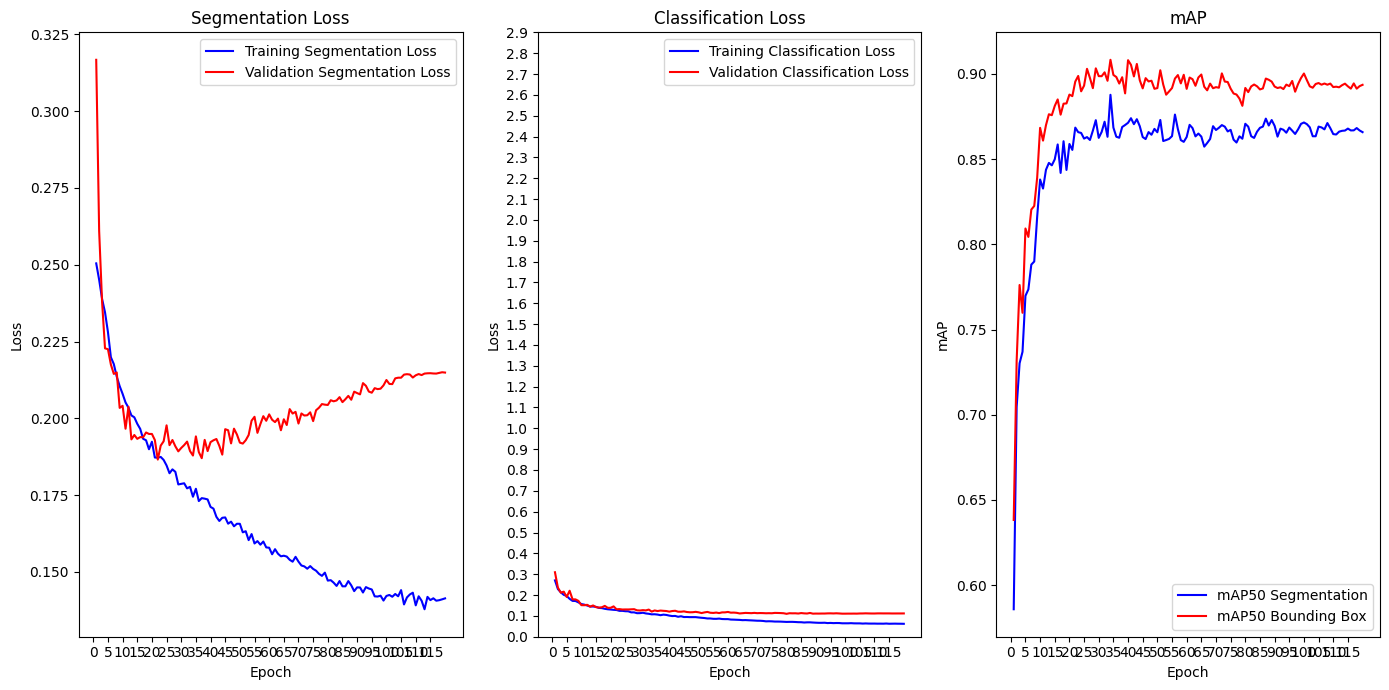

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with 1 row, 3 columns of subplots, and set figure size
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 7))

# Plot segmentation loss
# df['train/seg_loss'] = df['train/seg_loss'].clip(upper=3)
# df['val/seg_loss'] = df['val/seg_loss'].clip(upper=3)   

ax1.plot(df['epoch'], df['train/seg_loss'], label='Training Segmentation Loss', color='blue')
ax1.plot(df['epoch'], df['val/seg_loss'], label='Validation Segmentation Loss', color='red')
ax1.set_title('Segmentation Loss')
# ax1.set_yticks(np.arange(1, 3, 0.1))
ax1.set_xticks(np.arange(0, len(df['epoch']), 5))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot classification loss
ax2.plot(df['epoch'], df['train/cls_loss'], label='Training Classification Loss', color='blue')
ax2.plot(df['epoch'], df['val/cls_loss'], label='Validation Classification Loss', color='red')
ax2.set_title('Classification Loss')
ax2.set_yticks(np.arange(0, 3, 0.1))
ax2.set_xticks(np.arange(0, len(df['epoch']), 5))
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

# Plot mAP metrics
ax3.plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP50 Segmentation', color='blue')
ax3.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 Bounding Box', color='red')
# ax3.set_yticks(np.arange(0, 1, 0.05))
ax3.set_xticks(np.arange(0, len(df['epoch']), 5))
ax3.set_title('mAP')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('mAP')
ax3.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the figure
plt.show()

Evaluate With custome DICE & IOU

In [5]:
import cv2
import numpy as np
from ultralytics import YOLO
import pandas as pd
import yaml
import os

def compute_dice_iou(pred_mask, gt_mask):
    """Both masks are binary (0/1) numpy arrays."""
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    dice = (2. * intersection) / (pred_mask.sum() + gt_mask.sum() + 1e-7)
    iou = intersection / (pred_mask.sum() + gt_mask.sum() - intersection + 1e-7)
    return dice, iou

def evaluate_segmentation_model(model_path, data_yaml, conf=0.15):
    model = YOLO(model_path)
    
    model_dir = Path(model_path).parent.parent  
    csv_path = model_dir / 'IOU & DICE.csv'
    
    # Parse data.yaml to get validation paths
    with open(data_yaml) as f:
        data = yaml.safe_load(f)
    val_img_dir = Path(data['path']) / data['val']
    val_label_dir = val_img_dir.parent / 'labels'
    
    class_names = data['names']
    results_dict = {name: {'dice': [], 'iou': []} for name in class_names}
    results_dict['overall'] = {'dice': [], 'iou': []}
    
    img_files = list(val_img_dir.glob('*.jpg')) + list(val_img_dir.glob('*.png'))
    
    for img_path in tqdm(img_files, desc="Evaluating"):
        # Load image and ground truth mask
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]
        gt_mask = np.zeros((h, w), dtype=np.uint8)
        
        label_file = val_label_dir / f"{img_path.stem}.txt"
        if label_file.exists():
            with open(label_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 7:
                        continue
                    class_id = int(parts[0])
                    coords = np.array(parts[1:], dtype=np.float32).reshape(-1,2)
                    coords[:,0] *= w
                    coords[:,1] *= h
                    coords = coords.astype(np.int32)
                    cv2.fillPoly(gt_mask, [coords], 1)   # binary mask (1=tumor)
        
        # Run inference
        results = model(img, conf=conf, verbose=False)[0]
        
        if results.masks is None:
            pred_mask = np.zeros((h, w), dtype=np.uint8)
        else:
            # Combine all predicted masks (for binary evaluation)
            pred_mask = results.masks.data.cpu().numpy().sum(axis=0)
            pred_mask = (pred_mask > 0.5).astype(np.uint8)
        
        dice, iou = compute_dice_iou(pred_mask, gt_mask)
        results_dict['overall']['dice'].append(dice)
        results_dict['overall']['iou'].append(iou)
    
    # Aggregate results and create a DataFrame
    summary_rows = []
    for cls, metrics in results_dict.items():
        if len(metrics['dice']) == 0:
            continue
        mean_dice = np.mean(metrics['dice'])
        mean_iou  = np.mean(metrics['iou'])
        summary_rows.append({
            'Class': cls,
            'Mean_Dice': mean_dice,
            'Mean_IoU': mean_iou
        })
    
    df_summary = pd.DataFrame(summary_rows)
    
    # Print to console
    print("\n===== Segmentation Evaluation =====")
    print(df_summary.to_string(index=False))
    
    # Save to CSV in the run folder
    df_summary.to_csv(csv_path, index=False)
    print(f"\n✅ Results saved to: {csv_path}")
    
    return df_summary

# Usage
evaluate_segmentation_model(model_path=model_path, data_yaml='yolo_seg_dataset/dataset.yaml')

Evaluating: 100%|██████████| 860/860 [00:36<00:00, 23.87it/s]


===== Segmentation Evaluation =====
  Class  Mean_Dice  Mean_IoU
overall   0.817327    0.7215

✅ Results saved to: runs\segment\yolo_seg_from_cls_256(x)4_deepseek\IOU & DICE.csv


,Class,Mean_Dice,Mean_IoU
0,overall,0.817327,0.7215


# Test images

Test images for Both models pipline


image 1/1 e:\Amr college\Grad project\Models\YOLO_SEG\..\..\Dataset\2nd dataset classification\Training\meningioma_tumor\m (8).jpg: 224x224 meningioma 1.00, glioma 0.00, pituitary 0.00, no_tumor 0.00, 19.0ms
Speed: 6.3ms preprocess, 19.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Classification Result: meningioma (Confidence: 1.00)
Tumor found! Running Segmentation for meningioma

image 1/1 e:\Amr college\Grad project\Models\YOLO_SEG\..\..\Dataset\2nd dataset classification\Training\meningioma_tumor\m (8).jpg: 256x256 1 meningioma, 1352.7ms
Speed: 2.5ms preprocess, 1352.7ms inference, 7.0ms postprocess per image at shape (1, 3, 256, 256)
Diagnosis: Tumor successfully segmented.


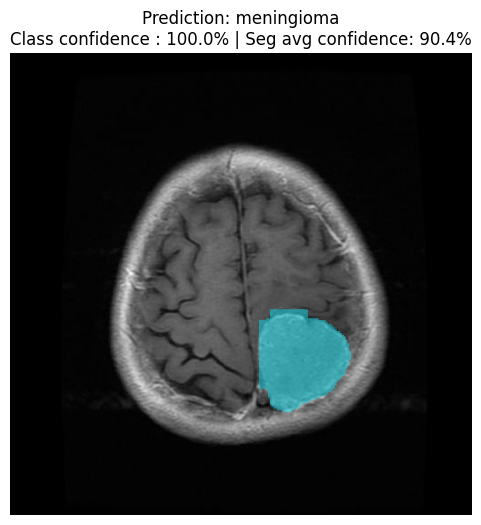

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# --- Configuration ---
# image_path = "../../Dataset/Test_images/glioma(1).jpeg"
image_path = "../../Dataset/2nd dataset classification/Training/meningioma_tumor/m (8).jpg"
conf_threshold = 0.25

# 1. Load your Classification Model
classifier_model = YOLO('../YOLO_classify/runs/classify/yolo_with_my_preproc3/weights/best.pt')

# 2. Load  Segmentation Model
segmentation_model = YOLO('runs/segment/yolo_seg_from_cls_256(x)4/weights/best.pt') 

# STAGE 1: CLASSIFICATION
class_results = classifier_model.predict(source=image_path)
class_result = class_results[0]

# For YOLO classification, probabilities are stored in result.probs
predicted_class_id = class_result.probs.top1
predicted_class_name = classifier_model.names[predicted_class_id]
confidence = class_result.probs.top1conf.item()

print(f"Classification Result: {predicted_class_name} (Confidence: {confidence:.2f})")

if predicted_class_name.lower() == "no_tumor":
    print("Diagnosis: no_tumor. Skipping segmentation.")
    image = cv2.imread(image_path)
    #display image
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap='gray')
    plt.title(f"Prediction: {predicted_class_name} | Confidence: {confidence*100:.1f}%")
    plt.axis("off")
    plt.show()


else:
    # STAGE 2: SEGMENTATION
    print(f"Tumor found! Running Segmentation for {predicted_class_name}")
    seg_results = segmentation_model.predict(source=image_path, conf=conf_threshold)
    seg_result = seg_results[0]
    
    if seg_result.masks is None or len(seg_result.masks) == 0:
        print("Warning: Classifier detected a tumor, but Segmenter couldn't find the boundaries.")
        image = cv2.imread(image_path)
        plt.figure(figsize=(6,6))
        plt.imshow(image, cmap='gray')
        plt.title(f"Prediction: {predicted_class_name} | Classification Confidence: {confidence*100:.1f}% \n"
                  f"The segmentor Couldn't find the image")
        plt.axis("off")
        plt.show()
        
    else:
        print("Diagnosis: Tumor successfully segmented.")
        
        # Get confidence scores for all detected masks
        confidences = seg_result.boxes.conf
        max_conf = confidences.max().item()
        avg_conf = confidences.mean().item() 
        
        # Generate clean overlay without boxes/labels
        plotted = seg_result.plot(boxes=False, labels=False)
        
        # Save the image
        cv2.imwrite("test_result.jpg", plotted)
        
        # Display with title including segmentation confidence
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        plt.title(f"Prediction: {predicted_class_name}\n"
                f"Class confidence : {confidence*100:.1f}% | Seg avg confidence: {avg_conf*100:.1f}%")
        plt.axis("off")
        plt.show()
        

Compare two Models


image 1/1 e:\Amr college\Grad project\Models\best run\..\..\Dataset\2nd dataset classification\Training\meningioma_tumor\m (29).jpg: 224x224 1 meningioma, 63.7ms
Speed: 41.9ms preprocess, 63.7ms inference, 34.3ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 e:\Amr college\Grad project\Models\best run\..\..\Dataset\2nd dataset classification\Training\meningioma_tumor\m (29).jpg: 224x224 1 meningioma, 32.6ms
Speed: 1.1ms preprocess, 32.6ms inference, 4.3ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 e:\Amr college\Grad project\Models\best run\..\..\Dataset\2nd dataset classification\Training\meningioma_tumor\m (29).jpg: 224x224 1 meningioma, 36.6ms
Speed: 1.3ms preprocess, 36.6ms inference, 4.7ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 e:\Amr college\Grad project\Models\best run\..\..\Dataset\2nd dataset classification\Training\meningioma_tumor\m (29).jpg: 256x256 1 meningioma, 46.3ms
Speed: 1.1ms preprocess, 46.3ms inference, 5.2ms postpr

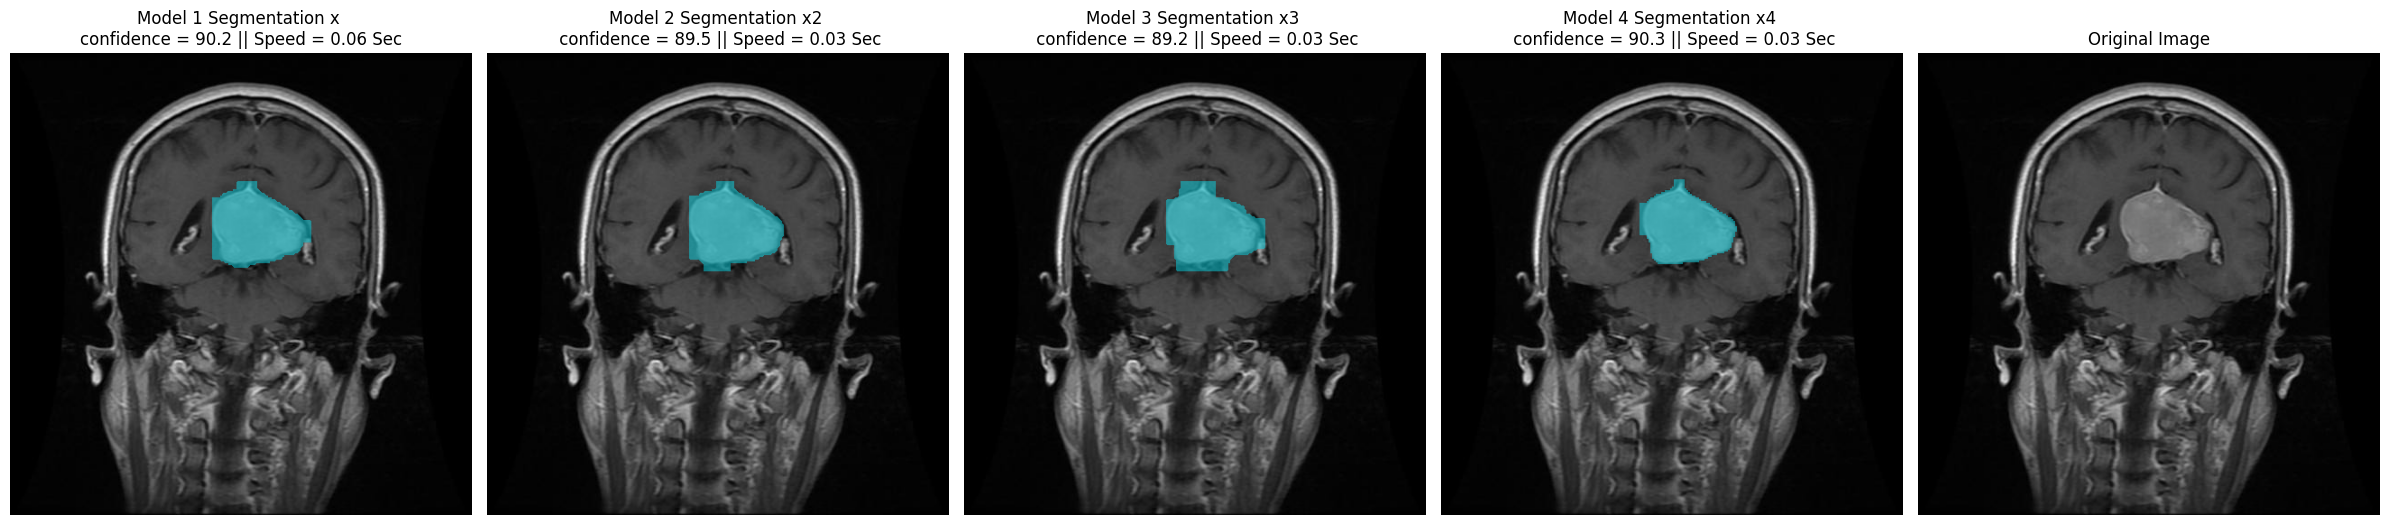

In [3]:
# Load both segmentation models
seg_model_1 = YOLO('Segmentation/yolo_seg_from_cls_224(x)/weights/best.pt')

seg_model_2 =  YOLO('Segmentation/yolo_seg_from_cls_224(x)2/weights/best.pt') 

seg_model_3 = YOLO('Segmentation/yolo_seg_from_cls_224(x)3/weights/best.pt')

seg_model_4 = YOLO('Segmentation/yolo_seg_from_cls_256(x)4/weights/best.pt')


# image_path = "../../Dataset/Test_images/glioma(2).jpeg"
image_path = "../../Dataset/2nd dataset classification/Training/meningioma_tumor/m (29).jpg"
source=cv2.imread(image_path)

conf_threshold = 0.25

# Run both models
result1 = seg_model_1.predict(source=image_path, conf=conf_threshold)[0]
conf=result1.boxes.conf
conf_mean1=conf.mean().item()
speed = result1.speed
speed1_max=max(speed.values())

result2 = seg_model_2.predict(source=image_path, conf=conf_threshold)[0]
conf2=result2.boxes.conf
conf_mean2=conf2.mean().item()
speed = result2.speed
speed2_max=max(speed.values())

result3 = seg_model_3.predict(source=image_path,conf=conf_threshold)[0]
conf3=result3.boxes.conf
conf_mean3=conf3.mean().item()
speed3=result3.speed
speed3_max = max(speed.values())

result4 = seg_model_4.predict(source=image_path,conf=conf_threshold)[0]
conf4=result4.boxes.conf
conf_mean4=conf4.mean().item()
speed4=result4.speed
speed4_max = max(speed.values())

# Plot side by side
fig, (ax1, ax2 , ax3,ax4,ax5) = plt.subplots(1, 5, figsize=(24, 12))

# Model 1 result
plot1 = result1.plot(labels=False, boxes=False)
ax1.imshow(cv2.cvtColor(plot1, cv2.COLOR_BGR2RGB))
ax1.set_title(F"Model 1 Segmentation x \n"
                F"confidence = {conf_mean1*100:.1f} || Speed = {speed1_max/1000:.2f} Sec")
ax1.axis("off")

# Model 2 result
plot2 = result2.plot(labels=False, boxes=False)
ax2.imshow(cv2.cvtColor(plot2, cv2.COLOR_BGR2RGB))
ax2.set_title("Model 2 Segmentation x2 \n "
                F"confidence = {conf_mean2*100:.1f} || Speed = {speed2_max/1000:.2f} Sec")
ax2.axis("off")

plot3=result3.plot(labels=False,boxes=False)
ax3.imshow(cv2.cvtColor(plot3,cv2.COLOR_BGR2RGB))
ax3.set_title("Model 3 Segmentation x3 \n "
                F"confidence = {conf_mean3*100:.1f} || Speed = {speed3_max/1000:.2f} Sec")
ax3.axis("off")


plot4=result4.plot(labels=False,boxes=False)
ax4.imshow(cv2.cvtColor(plot4,cv2.COLOR_BGR2RGB))
ax4.set_title("Model 4 Segmentation x4 \n "
                F"confidence = {conf_mean4*100:.1f} || Speed = {speed4_max/1000:.2f} Sec")
ax4.axis("off")

ax5.imshow(source)
ax5.set_title(f"Original Image")
ax5.axis("off")


plt.tight_layout()
plt.show()   

# Export into tflite

In [ ]:
# Export the trained model to TensorFlow Lite format
best_model.export(format='tflite')
best_model.export(format='tflite', int8=True)   # for integer quantization